**Isolation Forest Anomaly Detection**

In this project, we implement the Isolation Forest algorithm for unsupervised anomaly detection using the Breast Cancer dataset from scikit-learn. Anomaly detection aims to identify data points that deviate significantly from the normal pattern within a dataset. The Isolation Forest algorithm is based on the principle that anomalies are rare and easier to isolate compared to normal observations. It works by randomly selecting features and split values to construct decision trees, where data points that require fewer splits to be isolated are considered potential anomalies.

In this experiment, we treat the Breast Cancer dataset as an unsupervised learning problem, ignoring the class labels and focusing purely on the patterns in the feature space. The project follows a complete machine learning pipeline that includes data loading, preprocessing, feature scaling, model training, anomaly prediction, visualization, and evaluation. This approach demonstrates how Isolation Forest can effectively detect outliers in complex, multidimensional data. Although this dataset is typically used for classification, applying anomaly detection provides valuable insights into irregular data patterns — a concept that can be extended to domains such as financial fraud detection, sensor fault detection, or cryptocurrency market anomalies.

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


In [4]:
# Load Breast Cancer Dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Preview dataset
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Explore the Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


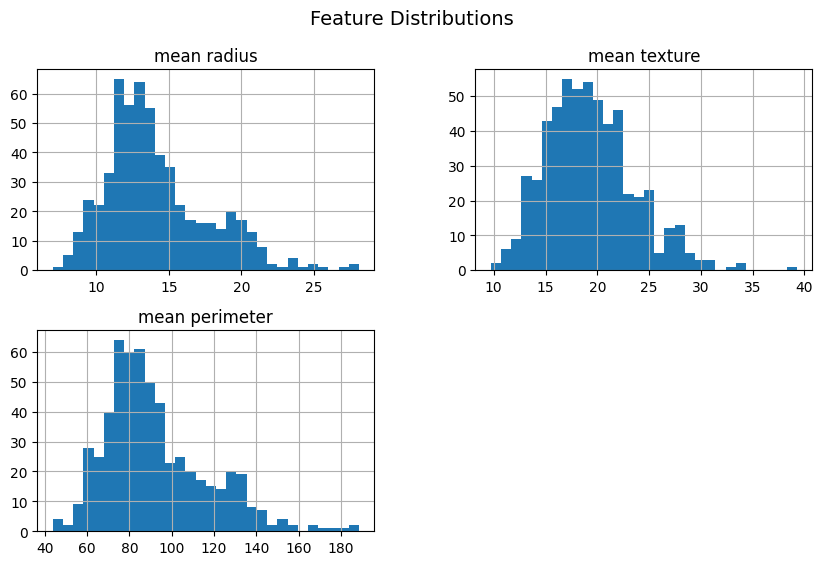

In [7]:
df[['mean radius', 'mean texture', 'mean perimeter']].hist(bins=30, figsize=(10, 6))
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

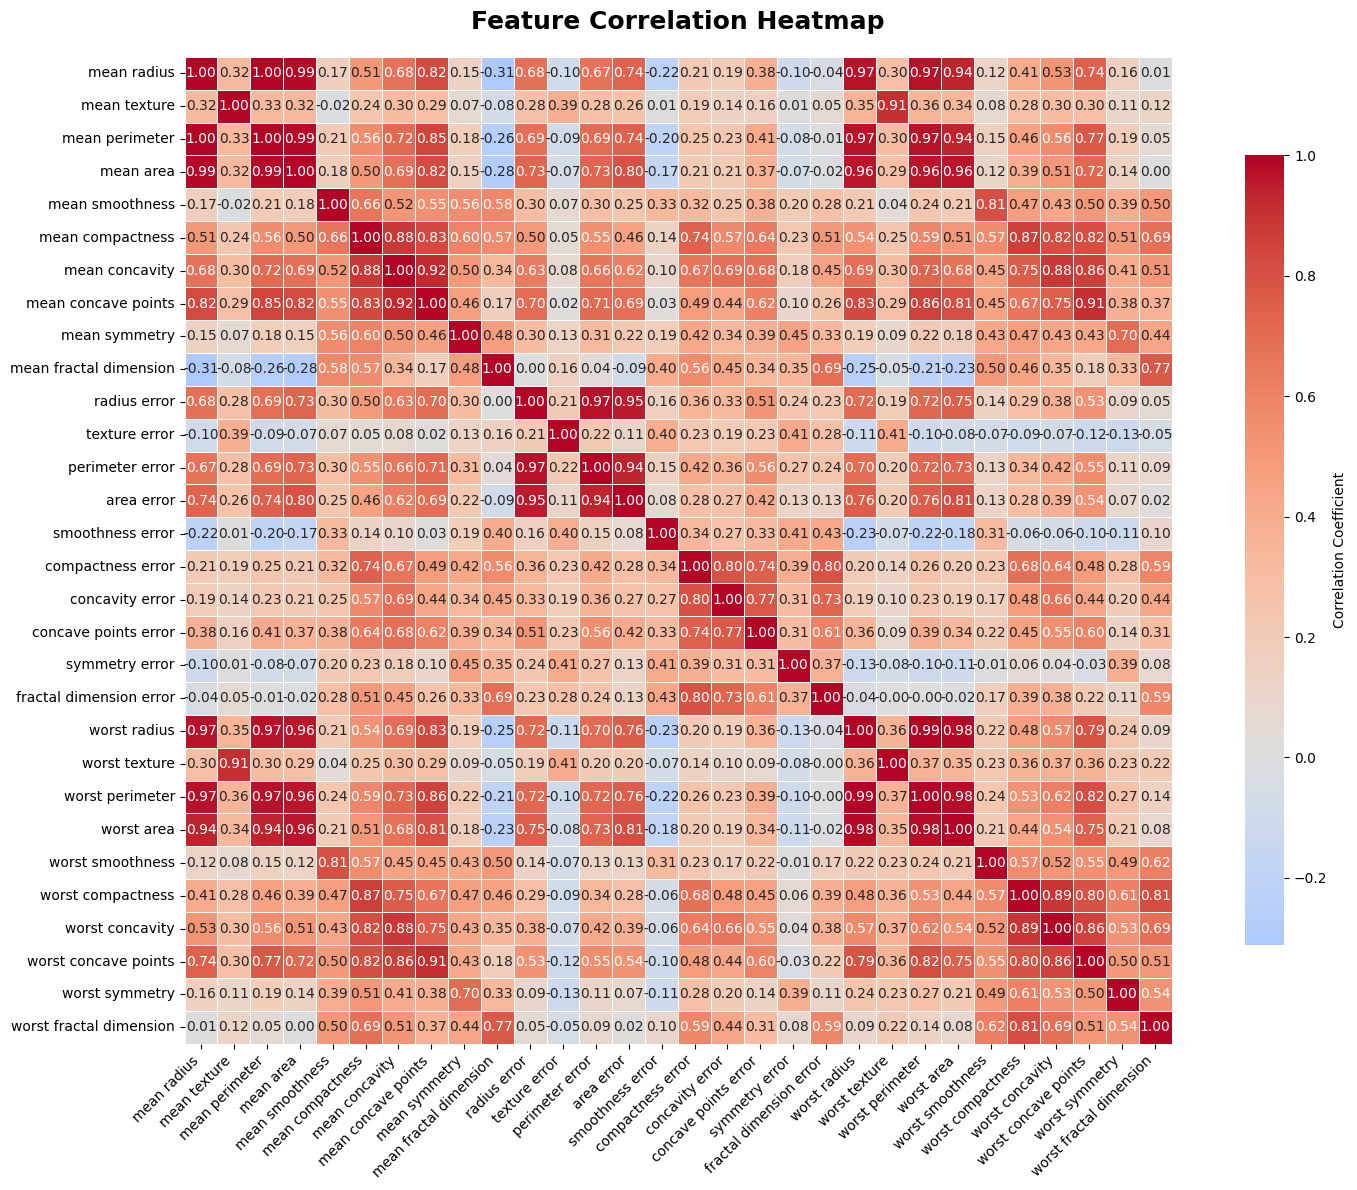

In [9]:
# Compute correlation matrix (excluding target column)
corr_matrix = df.drop(columns=['target']).corr()
plt.figure(figsize=(16, 12))
# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Feature Correlation Heatmap", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# Data Preprocessing
X = df.drop(columns=['target'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [11]:
# Initialize the Isolation Forest Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

In [12]:
# Train the model
iso_forest.fit(scaled_df)


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [13]:
# Predict Anomalies
df['anomaly'] = iso_forest.predict(scaled_df)

# Map predictions
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Count how many anomalies
df['anomaly_label'].value_counts()


,count
anomaly_label,
Normal,540
Anomaly,29


In [14]:
# Compute Anomaly Scores
df['anomaly_score'] = iso_forest.decision_function(scaled_df)
df[['anomaly_label', 'anomaly_score']].head()


,anomaly_label,anomaly_score
0,Anomaly,-0.042286
1,Normal,0.091729
2,Normal,0.094818
3,Anomaly,-0.092113
4,Normal,0.077446


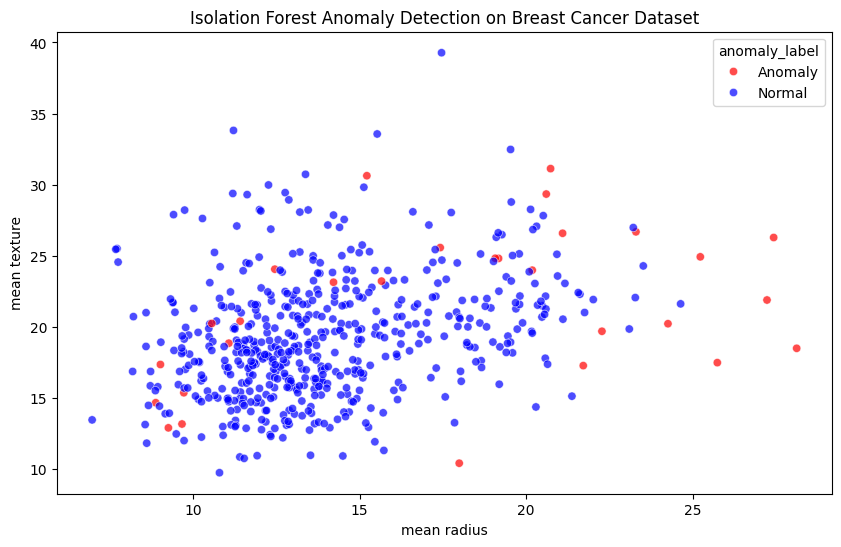

In [15]:
#  Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='mean radius', y='mean texture',
    hue='anomaly_label',
    palette={'Normal': 'blue', 'Anomaly': 'red'},
    alpha=0.7
)
plt.title("Isolation Forest Anomaly Detection on Breast Cancer Dataset")
plt.show()


In [16]:
# Analyze and Interpret ResultsStep 10: Evaluation
total_points = len(df)
anomaly_points = df[df['anomaly_label'] == 'Anomaly']
print(f"Total points: {total_points}")
print(f"Anomalies detected: {len(anomaly_points)} ({len(anomaly_points)/total_points*100:.2f}%)")

# Compare average values
df.groupby('anomaly_label').mean(numeric_only=True).head(10)


Total points: 569
Anomalies detected: 29 (5.10%)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,anomaly,anomaly_score
anomaly_label,,,,,,,,,,,,,,,,,,,,,
Anomaly,17.885931,21.484138,120.763448,1104.589655,0.113724,0.218756,0.262885,0.116583,0.218403,0.073694,...,1619.841379,0.152831,0.534683,0.649862,0.211168,0.353383,0.110453,0.206897,-1.0,-0.050764
Normal,13.925439,19.171796,90.422667,630.738519,0.095428,0.098196,0.079450,0.045285,0.179162,0.062212,...,840.882222,0.131270,0.239206,0.251906,0.109421,0.286676,0.082522,0.650000,1.0,0.119238


In [17]:
# Hyperparameter Tuning
for contamination in [0.01, 0.03, 0.05, 0.1]:
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(scaled_df)
    preds = model.predict(scaled_df)
    anomalies = np.sum(preds == -1)
    print(f"Contamination={contamination} → Anomalies Detected: {anomalies}")


Contamination=0.01 → Anomalies Detected: 6
Contamination=0.03 → Anomalies Detected: 18
Contamination=0.05 → Anomalies Detected: 29
Contamination=0.1 → Anomalies Detected: 57


In [18]:
 # Save Model
import joblib
joblib.dump(iso_forest, "Isolation_Forest_BreastCancer.pkl")

# Load later
# iso_forest = joblib.load("Isolation_Forest_BreastCancer.pkl")

['Isolation_Forest_BreastCancer.pkl']

**Conclusion:-**
In this implementation, we successfully implemented the Isolation Forest algorithm to perform unsupervised anomaly detection on the Breast Cancer dataset. By treating the dataset without its labels, we demonstrated how the algorithm can identify unusual data points that differ from the general distribution of normal samples. The Isolation Forest effectively separated potential outliers by isolating them faster within randomly constructed decision trees, showcasing its ability to handle high-dimensional, complex data efficiently.

Through feature scaling, model training, anomaly scoring, and visualization, we gained insights into the patterns of normal and abnormal instances. The results highlight the robustness of Isolation Forest for detecting rare or irregular patterns in large datasets — making it a valuable approach for real-world applications such as fraud detection, network intrusion monitoring, fault detection in IoT systems, and financial or cryptocurrency anomaly analysis.